In [1]:
#https://platform.openai.com/docs/guides/tools-code-interpreter

In [2]:
from dotenv import load_dotenv
_ = load_dotenv()

import json
import openai
from openai import OpenAI

client = OpenAI()

In [3]:
from sklearn.datasets import load_iris
iris = load_iris()

In [4]:
import pandas as pd
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].apply(lambda x: iris.target_names[x])
df = df.drop('species', axis=1)
df = df.rename(columns={'species_name': 'species'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
df.to_csv('iris.csv', index=False)

In [6]:
# ----------------------------
# 2. Upload file
# ----------------------------
file_obj = client.files.create(file=open("iris.csv", "rb"), purpose="user_data")
file_id = file_obj.id
print(f"Uploaded file ID: {file_id}")

Uploaded file ID: file-QZWejQsLZoYnxLaDvAVX3t


In [7]:

instructions = """
You are a biologist and statistician.
You have collection of sepal and petal dimensions for 150 iris flowers.
The csv contains 1 header row, no index column, 4 measurement columns and a species column.
Randomly select 80% of the data rows with a random random state to learn and predict the species of the other 20%.
Produce an ASCII style confusion matrix of the prediction results as well as a PNG version of the confusion matrix that I can download.
"""

# by default it actually produced a PNG confusion matrix but 
# I can't quite figure out how to extract an image produced here.

#This is a perishable container that I will not have access to after this query.
#Save the confusion matrix as a globally accessible File and return the file_id so that I may download it later.

#Emit the entire confustion matrix PNG as base64 in its own attribute in the response so that I can then print in Python

#          "text": "Here is your confusion matrix as a base64-encoded PNG image. You can decode and display it in Python using standard 
#libraries such as matplotlib or PIL.\n\n```json\n{\n  \"confusion_matrix_png_base64\": \"iVBORw0KGgoAAAANSUhEUgAABLAAAASwCAYAAADrIbPPAAAAOXRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjYuMywg...<truncated>\"\n}\n```\n
#\nReplace `...<truncated>` with the full string below for use in your Python environment.\n\nLet me know if you'd like the full base64 string or the code to decode and print it!",


In [8]:
resp = client.responses.create(
    model="gpt-4.1",
    tools=[
        {
            "type": "code_interpreter",
            "container": {
                "type": "auto",
                "file_ids": [file_id]
            }
        }
    ],
    input=[
        {"role": "system", "content": instructions}],
#        {"role": "user", "content": q}],

    temperature=0
)


In [9]:
print(resp.output)

[ResponseCodeInterpreterToolCall(id='ci_0ae25ef7341b8de90068fe4fd82bb88197b2b9b9d6f3b7e9bf', code="import pandas as pd\n\n# Load the iris dataset\nfile_path = '/mnt/data/file-QZWejQsLZoYnxLaDvAVX3t-iris.csv'\ndf = pd.read_csv(file_path)\n\n# Display the first few rows to confirm structure\ndf.head()", container_id='cntr_68fe4fd63dac81909ba836a108a13ab3011eb1a42860ae41', outputs=None, status='completed', type='code_interpreter_call'), ResponseCodeInterpreterToolCall(id='ci_0ae25ef7341b8de90068fe4fe273a08197897831cf30621e18', code='from sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\nimport numpy as np\n\n# Prepare features and target\nX = df.iloc[:, :-1]\ny = df[\'species\']\n\n# Split the data (80% train, 20% test) with a random random_state\nrandom_state = np.random.randint(0, 10000)\nX_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random

In [10]:
pretty_json_output = resp.model_dump_json(indent=2)
print(pretty_json_output)

{
  "id": "resp_0ae25ef7341b8de90068fe4fd2e5a48197960139cfab76f0d4",
  "created_at": 1761497043.0,
  "error": null,
  "incomplete_details": null,
  "instructions": null,
  "metadata": {},
  "model": "gpt-4.1-2025-04-14",
  "object": "response",
  "output": [
    {
      "id": "ci_0ae25ef7341b8de90068fe4fd82bb88197b2b9b9d6f3b7e9bf",
      "code": "import pandas as pd\n\n# Load the iris dataset\nfile_path = '/mnt/data/file-QZWejQsLZoYnxLaDvAVX3t-iris.csv'\ndf = pd.read_csv(file_path)\n\n# Display the first few rows to confirm structure\ndf.head()",
      "container_id": "cntr_68fe4fd63dac81909ba836a108a13ab3011eb1a42860ae41",
      "outputs": null,
      "status": "completed",
      "type": "code_interpreter_call"
    },
    {
      "id": "ci_0ae25ef7341b8de90068fe4fe273a08197897831cf30621e18",
      "code": "from sklearn.model_selection import train_test_split\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\nimpo

In [11]:
data = json.loads(resp.model_dump_json(include={"output"}))

In [12]:
#https://curlconverter.com/python/
import os
import requests

headers = {
    'Authorization': 'Bearer ' + os.getenv('OPENAI_API_KEY', ''),
}

response = requests.get('https://api.openai.com/v1/containers/cntr_68fe4be12c1081918cefb77e4074d7220fd508a4a3c17cf6/files/cfile_68fe4bfef1f4819182888ce456e4d13f/content', headers=headers)

#import base64, io
from IPython.display import Image, display


import pandas as pd

# Load the iris dataset
file_path = '/mnt/data/file-QZWejQsLZoYnxLaDvAVX3t-iris.csv'
df = pd.read_csv(file_path)

# Display the first few rows to confirm structure
df.head()
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Prepare features and target
X = df.iloc[:, :-1]
y = df['species']

# Split the data (80% train, 20% test) with a random random_state
random_state = np.random.randint(0, 10000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

# Train a classifier
clf = RandomForestClassifier(random_state=random_state)
clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)

# Prepare ASCII confusion matrix
ascii_matrix = "Confusion Matrix (rows: true, cols: 

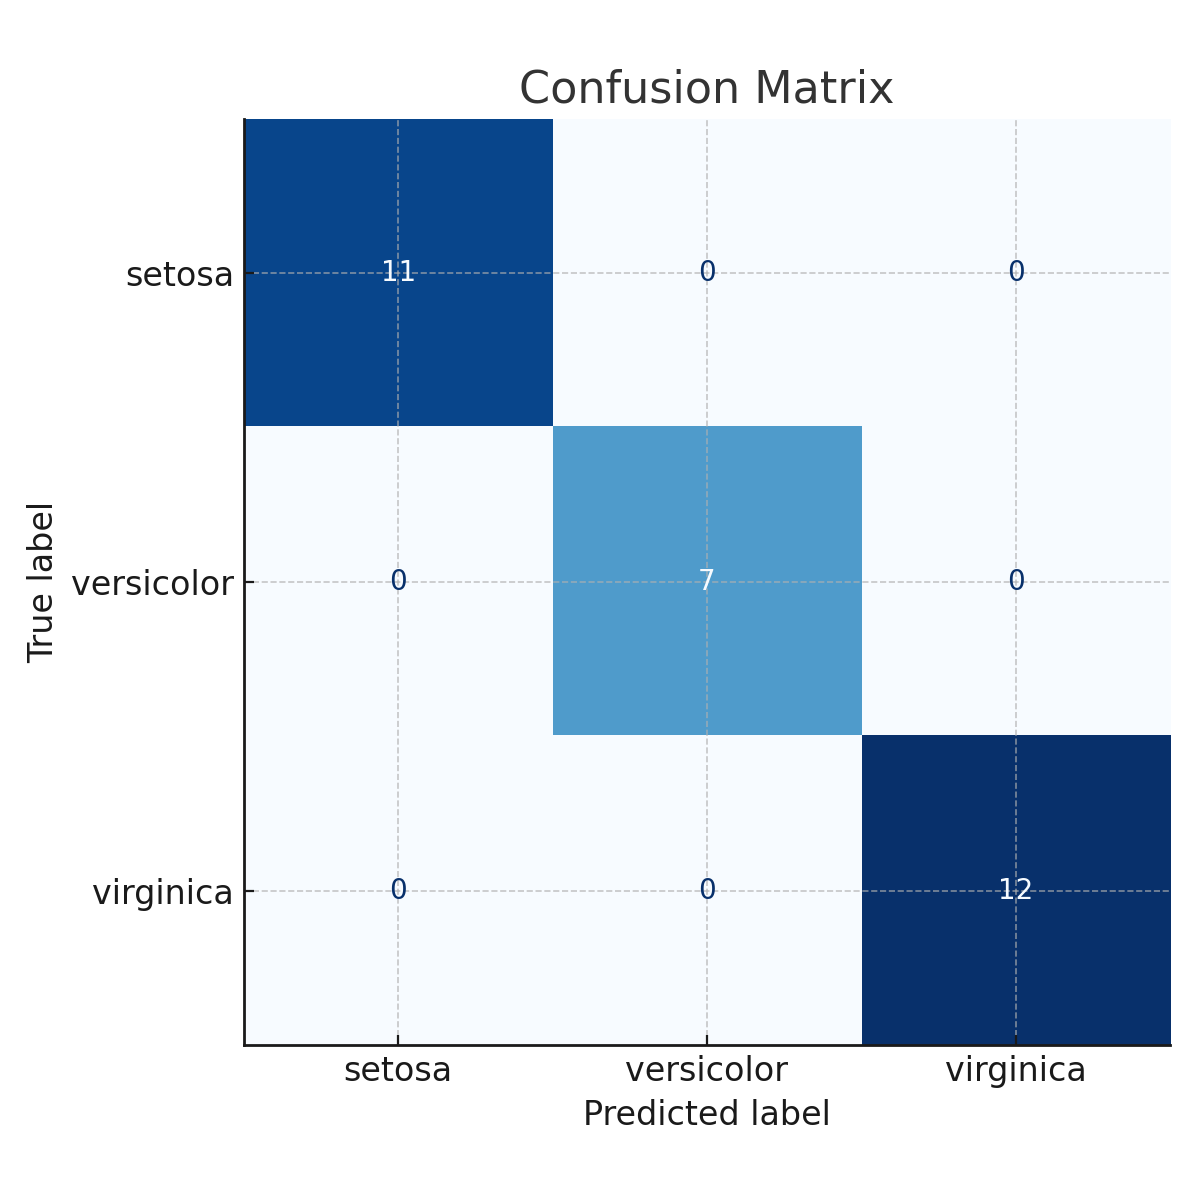

In [13]:
# Loop through the list of dictionaries
for item in data['output']:
    # Each 'item' in this loop is a dictionary
    if 'code' in item:
        print(item['code'])
    if 'content' in item:
        for i in item['content']:
            if 'text' in i:
                print(i['text'])
            if 'annotations' in i:
                for j in i['annotations']:
                    print(j['container_id'])
                    print(j['file_id'])
                    print(j['filename'])
                    binary_file = requests.get(
                        f"https://api.openai.com/v1/containers/{j['container_id']}/files/{j['file_id']}/content",
                            headers=headers)
                    display(Image(binary_file.content))


In [14]:

print(client.files.delete(file_id))


FileDeleted(id='file-QZWejQsLZoYnxLaDvAVX3t', deleted=True, object='file')
